# [2주차] [5. ML] 과제
- **과제 목적**: Titanic 데이터 하나로 처음부터 ML의 과정을 끝까지 직접 밟아봅니다. 라이브러리 함수를 호출하는 데서 끝내지 않고, 학습의 핵심(loss, gradient descent)과 평가의 핵심(confusion matrix와 4대 지표)을 **손으로 직접 계산**해 개념을 체화합니다. 이어서 두 모델을 동일 조건에서 비교하고 성능 차이의 원인을 모델 구조 관점에서 해석합니다. 마지막 심화에서는 수업에서 그림으로만 본 overfitting을 실험으로 직접 재현합니다.

> ⚠️ **주의**: LLM를 써도 좋지만, **판단·검증·해석은 반드시 직접** 수행하고 사용 내역을 `## 3`에 기록하세요.


## 0. 환경 설정

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

MY_SEED = 3001 # TODO: 랜덤한 숫자
np.random.seed(MY_SEED)

#  Titanic 데이터를 사용
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. 필수 과제

### 1-1. ML 문제 정의 (수업 §2)

코드를 짜기 전에, 이 문제를 ML 문제로 **정식화**합니다. 아래 빈칸을 채우세요.

- 우리는 이 데이터셋에서 타이타닉 탑승자의 생존 여부를 맞춰야합니다. **target(label)**은 어떤 column인가? → `survived`
- 이 데이터에는 label이 (있다). 따라서 학습 방식은 `_ 지도/준지도__`학습이다.
- target이 (범주형) 이므로, 이 문제는 (분류) 문제다. → 정답: `범주형, 분류`
- 학습 전에 데이터를 train/test로 나누는 이유를 **본인의 언어로** 한 문장: `__train 데이터에 과적합된 모델은 학습 데이터에서는 높은 성능을 보이지만, test 데이터에서는 성능이 저하될 수 있어서 모델의 일반화 성능을 평가하기 위해서이다.`


### 1-2. 전처리와 데이터 분할

아래 TODO를 채우고, **각 주석의 빈칸에 '왜 이 단계가 필요한지'를 직접 적으세요.


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

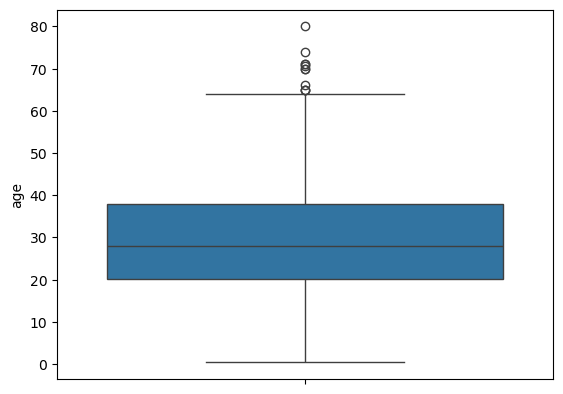

In [24]:
# 사용할 feature와 target 선택
features = ["pclass", "sex", "age", "fare"]
target = "survived"

df = titanic[features + [target]].copy()
sns.boxplot(df['age'])
df['age'].describe()

In [25]:
# 사용할 feature와 target 선택
features = ["pclass", "sex", "age", "fare"]
target = "survived"

df = titanic[features + [target]].copy()

# [빈칸] age의 결측치를 중앙값으로 채우는 이유 (평균이 아니라 중앙값을 쓰는 이유 포함): age의 분포를 .describe() 혹은 boxplot을 이용해서 보게 되면 이상치가 다수 존재하므로 상대적으로 이상치에 영향을 덜 받는 중앙값을 이용한다.  
df["age"] = df["age"].fillna(df["age"].median())

# [빈칸] sex를 0/1 숫자로 바꾸는 이유 (모델 입장에서 설명): 모델 입장에서는 데이터가 숫자로 이루어져 있어야 하므로 0,1로 바꾸어 수학적 연산이 가능하도록 한다.
df["sex"] = (df["sex"] == "female").astype(int)

df = df.dropna()

X = df[features]
y = df[target]

# TODO: train/test를 8:2로 분할하세요. random_state=MY_SEED 사용
# [빈칸] stratify=y 옵션을 주는 이유: 원본 데이터의 label 비율을 train과 test에서도 동일하게 유지하기 위해서이다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state= MY_SEED,
    stratify=y
)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train 생존율: {y_train.mean():.3f}, test 생존율: {y_test.mean():.3f}")

train: (623, 4), test: (268, 4)
train 생존율: 0.384, test 생존율: 0.384


### 1-3. Gradient Descent 손계산 (수업 §3)

수업에서 "학습 = loss를 낮추는 방향으로 파라미터를 조금씩 갱신"이라고 했습니다. 이걸 **가장 작은 예제로 직접 계산**합니다.

**설정**: 데이터 3개 $(x, y) = (1,2), (2,4), (3,6)$, 모델 $\hat{y} = wx$ (절편 없음), loss는 MSE

$$L(w) = \frac{1}{3}\sum_{i=1}^{3}(y_i - wx_i)^2, \qquad \frac{\partial L}{\partial w} = -\frac{2}{3}\sum_{i=1}^{3} x_i(y_i - wx_i)$$

**문제**: $w_0 = 0$, learning rate $\eta = 0.1$에서 시작하여 **gradient descent를 3회 반복해 직접 계산**하고, **각 단계에서 $w$가 왜 그 방향으로, 왜 그만큼 움직였는지** 설명하세요. (계산기는 써도 되지만 코드로 먼저 답을 구하면 안 됩니다 — 아래 검증 셀은 손계산이 끝난 뒤에 실행)

| 반복 | 현재 $w$ | 각 데이터의 오차 $(y_i - wx_i)$ | gradient $\frac{\partial L}{\partial w}$ | 갱신된 $w$ |
|---|---|---|---|---|
| 1 | 0 | [2,4,6] | -18.6 | 1.86 |
| 2 | 1.86 | [0.14, 0.28, 0.42] | -1.30 | 1.99|
| 3 | 1.99 | [0.01, 0.02, 0.03] | -0.09 | 1.999 |

**서술**: 매 반복마다 gradient의 크기가 어떻게 변했고, 그것이 $w$의 이동량과 어떤 관계인가? 이 과정이 언제, 왜 멈추게 될까? → `매 반복마다 gradient 크기가 전체적으로 줄어드는 경향을 보인다. w는 gradient의 크기와 이동량이 비례 관계를 가지고 있다. 이 과정은 graident가 0이 될 경우, 설정한 최대 반복 횟수에 도달 할 경우에 멈추게 될 것이다.


In [26]:
# ===== 손계산 검증용 셀 (표를 다 채운 뒤에 실행하세요) =====
# 주의: 위에서 만든 target y(Series)를 덮어쓰지 않도록 여기서는 gx, gy 라는 별도 변수를 쓴다.
gx = np.array([1, 2, 3])
gy = np.array([2, 4, 6])



w = 0.0
lr = 0.1

for step in range(1, 4):
    # TODO: 위 수식대로 gradient를 코드로 옮기세요
    grad = -2/len(gx) * np.sum(gx*(gy-w*gx))   # 힌트: -2/len(gx) * np.sum(...)

    # [빈칸] gradient의 '반대 방향'으로 이동하는 이유: loss function의 값이 최소화하는 매개변수를 찾기 위해서이다.
    w = w - lr * grad

    loss = np.mean((gy - w * gx) ** 2)
    print(f"step {step}: grad = {grad:+.4f}, w = {w:.4f}, loss = {loss:.4f}")

# 손계산 결과와 출력이 일치하는지 확인하고, 다르면 어디서 틀렸는지 찾아 적으세요: 손으로 계산하는 과정에서 소수점 둘째 자리까지만 사용하고 뒷부분을 절사했기 때문이다.

step 1: grad = -18.6667, w = 1.8667, loss = 0.0830
step 2: grad = -1.2444, w = 1.9911, loss = 0.0004
step 3: grad = -0.0830, w = 1.9994, loss = 0.0000


### 1-4. 두 모델 학습과 비교

수업에서 "모든 알고리즘은 (f의 형태 / loss / 찾는 방법)에 대한 서로 다른 답"이라고 했습니다. 형태가 전혀 다른 두 모델을 **같은 데이터, 같은 조건**에서 학습시켜 비교합니다.

- **모델 A**: Logistic Regression (선형 + sigmoid)
- **모델 B**: Decision Tree (재귀 분할)


In [27]:
# 과정 확인 장치: train과 test 성능을 모두 기록합니다
results = {}

# TODO: 모델 A — LogisticRegression을 학습시키세요 (max_iter=1000)
model_a = LogisticRegression(max_iter=1000)
model_a.fit( X_train, y_train)

# TODO: 모델 B — DecisionTreeClassifier를 학습시키세요 (random_state=MY_SEED)
model_b = DecisionTreeClassifier(random_state=MY_SEED)
model_b.fit(X_train, y_train)

for name, model in [("Logistic Regression", model_a), ("Decision Tree", model_b)]:
    # [빈칸] train 정확도와 test 정확도를 '둘 다' 기록하는 이유 (수업 §3의 개념과 연결해서): train 데이터에 과적합된 모델은 학습 데이터에서는 높은 성능을 보이지만, test 데이터에서는 성능이 저하될 수 있어서 확인하기 위해서이다.
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = (train_acc, test_acc)
    print(f"{name:20s} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

Logistic Regression  | train acc: 0.7865 | test acc: 0.8097
Decision Tree        | train acc: 0.9791 | test acc: 0.8134


### 1-5. 평가지표 직접 유도

수업에서 "Confusion Matrix 하나에서 4개 지표가 전부 유도된다"고 했습니다. **sklearn의 지표 함수를 쓰기 전에**, TP/TN/FP/FN으로부터 직접 계산해 봅니다. (모델 A 기준)


In [28]:
y_pred = model_a.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# sklearn의 confusion_matrix 배치: [[TN, FP], [FN, TP]]
TN, FP = cm[0]
FN, TP = cm[1]
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

# TODO: 아래 4개 지표를 TP/TN/FP/FN '만으로' 직접 계산하세요 (sklearn 함수 사용 금지)
my_accuracy  = (TP+TN)/(TP+FP+FN+TN)
my_precision = TP/(TP+FP)   # [빈칸] precision의 분모에 들어가는 것과 그 의미: ______
my_recall    = TP/(TP+FN)   # [빈칸] recall의 분모에 들어가는 것과 그 의미: ______
my_f1        = 2*(my_precision*my_recall)/(my_precision+my_recall)  # 힌트: precision과 recall의 조화평균

# 검증: sklearn과 비교 (통과하지 못하면 수식을 다시 확인)
assert np.isclose(my_accuracy,  accuracy_score(y_test, y_pred))
assert np.isclose(my_precision, precision_score(y_test, y_pred))
assert np.isclose(my_recall,    recall_score(y_test, y_pred))
assert np.isclose(my_f1,        f1_score(y_test, y_pred))
print("✅ 4개 지표 모두 sklearn과 일치")

Confusion Matrix:
 [[143  22]
 [ 29  74]]
TP=74, TN=143, FP=22, FN=29
✅ 4개 지표 모두 sklearn과 일치


### 1-6. 결과 해석 (필수 서술)

아래 4개 질문에 **본인의 실험 결과 수치를 근거로** 답하세요. (수치 없이 일반론만 쓰면 감점)

1. **왜 이러한 결과가 나왔는가?** — 두 모델의 test 정확도는 각각 얼마였고, 이 데이터에서 그 정도 성능이 나온 이유를 feature 관점에서 추측하면? → `Logistic Regression의 test 정확도는 0.8097이고, Decision Tree의 test 정확도는 0.8134이다. feature의 관점에서 생각을 해보면 feature 들이 모두 숫자형으로 이루어진 것이 아니라 범주형 변수들이 있어서 트리 모델의 성능이 더 높게 나왔을 수 있다.`
2. **두 모델의 성능 차이는 어디에서 발생했는가?** — `train acc와 test acc의 '차이'가 두 모델에서 어떻게 달랐는가? 이를 모델 구조(선형 경계 vs 재귀 분할)의 관점에서 해석하면? → Logistic Regression은 선형 결합을 sigmoid 함수에 통과시켜 0~1 사이의 확률로 변환하며, 기본 임계값인 0.5를 넘을 경우 Positive로 판단한다. 이러한 선형 결정 경계는 모델의 표현력을 제한하기 때문에 학습 데이터에 대해서도 지나치게 복잡한 패턴을 학습하지 못하며, 그 결과 train acc: 0.7865, test acc: 0.8097로 두 값의 차이가 크지 않다. 반면 Decision Tree는 데이터를 가장 잘 나누는 질문을 고르고 이를 반복적으로 적용하는 재귀적 분할을 통해 학습을 진행한다. 이 과정에서 트리는 학습 데이터의 세부적인 패턴, 심지어 노이즈까지 반영할 수 있을 만큼 깊고 복잡한 경계를 만들 수 있다. 그 결과 train acc: 0.9791, test acc: 0.8134로 train acc는 매우 높지만 test acc는 Logistic Regression과 비슷한 수준에 그쳐, 두 정확도 사이에 큰 격차가 발생한다.`

3. **실험 조건을 변경하면 결과가 어떻게 달라지는가?** — `MY_SEED`를 다른 값으로 바꿔 1-2 ~ 1-4를 다시 실행해 보고, 어떤 수치가 얼마나 흔들렸는지 기록. 이 흔들림을 줄이는 방법으로 수업에서 배운 것은? → `MY_SEED 를 45로 할 경우, Logistic Regression의 train acc은 0.8010, test acc은 0.7836이며, Decision Tree 의 train acc은 0.9823이고, test acc은 0.7799이 나왔다. 이를 통해서 train acc의 성적은 크게 달라지지 않았지만, Decision tree의 test accuaracy가 흔들린 것을 알 수 있다.`

4. **예상과 다른 결과가 나왔다면 그 원인은 무엇인가?** — 과제를 시작하기 전 예상과 달랐던 지점 하나와, 그 원인에 대한 본인의 가설: → `과제를 시작하기 전에는 구조가 더 복잡한 Decision Tree가 Logistic Regression보다 test acc도 더 높을 것이라 예상했다. 하지만 실제로는 train acc는 Decision Tree가 훨씬 높았지만 test acc는 두 모델이 비슷한 수준(0.8097 vs 0.8134)에 그쳤다. 이유를 생각해보면 Decision Tree는 depth를 제한하지 않고 학습을 하여서 과접합이 발생했던 것 같다.`

## 2. 심화 과제 (선택)

### 2-1. Overfitting 직접 재현하기

 overfitting/underfitting curve를 **본인 데이터로 직접 그립니다.** Decision Tree의 `max_depth`를 1부터 15까지 바꿔가며 train/test 정확도를 기록하세요.


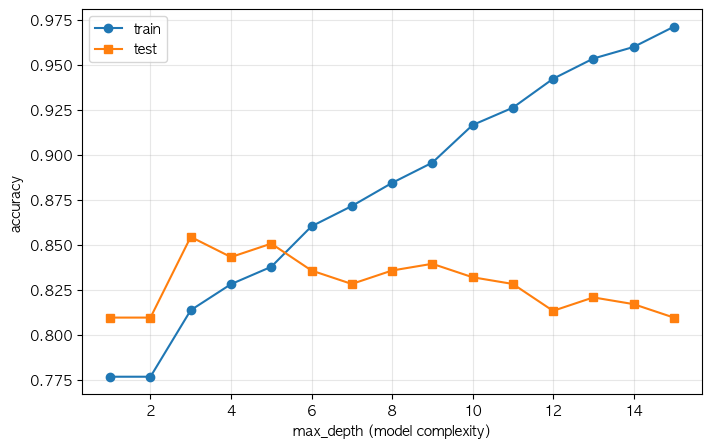

In [ ]:
depths = range(1, 16)
train_scores, test_scores = [], []

for d in depths:
    # TODO: max_depth=d인 DecisionTreeClassifier를 학습시키고
    #       train/test 정확도를 각 리스트에 추가하세요
    model_c=DecisionTreeClassifier(max_depth=d, random_state=MY_SEED)
    model_c.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model_c.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model_c.predict(X_test)))

# 밑에 그래프를 그릴경우 폰트가 깨져서 이 코드를 추가했습니다
import matplotlib.pyplot as plt
import matplotlib as mpl

# macOS 기본 내장 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False 

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="train")
plt.plot(depths, test_scores, marker="s", label="test")
# Colab 기본 환경엔 한글 폰트가 없어 제목/라벨은 영문으로 둔다(한글이면 □로 깨짐)
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 해석 (필수):
# - 그래프에서 underfitting 구간과 overfitting 구간은 각각 어디인가? → 그래프에서 underfitting 되는 구간은 max_depth가 3보다 작을 경우이고, overfitting이 되는 구간은 max_depth가 3보다 커지는 구간이다. 왜냐하면 depth가 3보다 클 경우 test accuracy가 줄어들기 때문이다.
# - 본인 데이터 기준 최적의 max_depth와 그렇게 판단한 근거는? →  max_depth=3에서 test accuracy가 가장 높게 나타났으며, 이보다 depth를 늘려도 train accuracy만 계속 증가할 뿐 test accuracy는 오히려 하락하기 때문이다. 즉 3은 underfitting과 overfitting 사이에서 일반화 성능이 가장 좋은 지점이다.
# - 이 그래프가 수업의 "train loss만 낮추는 건 쉽다"는 문장과 어떻게 연결되는가? → 위 그래프를 보면 max_depth를 계속 늘리기만 해도 train accuracy는 거의 1에 가까울 정도로 쉽게 높일 수 있다는 것을 확인할 수 있다. 모델이 복잡해질수록 train 데이터에 대해서는 얼마든지 더 잘 맞출 수 있기 때문이다. 

### 2-2. 비지도학습 미리보기 — label을 가리면 무엇이 보일까?

지금까지는 `survived`라는 label을 알고 학습했습니다(지도학습). 이번엔 **label을 일부러 가리고**, 데이터의 구조만으로 무엇이 보이는지 확인합니다.


In [33]:
print(df['age'].describe())
print(df['fare'].describe())

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


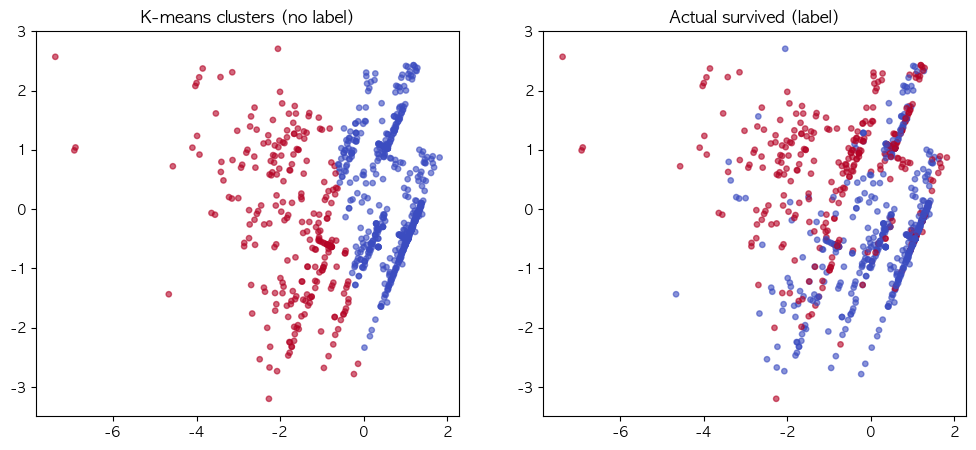

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# [빈칸] PCA/K-means 전에 스케일링이 필요한 이유 (fare와 age의 단위를 생각해 보세요): PCA와 kmeans는 변수간의 거리를 기반으로 그룹을 나누거나 아니면 차원을 축소한다. 그런데 위 데이터를 보게 되면 데이터 변수들 별로 단위가 다른 것을 확인 할 수 있다. 그래서 만약에 스케일링을 하지 않고 그대로 진행할 경우에는 fare의 영향일 절대적으로 클것으로 예상이 된다. 그래서 데이터에 스케일링 진행이 필요하다.
X_scaled = StandardScaler().fit_transform(X)

# TODO: PCA로 2차원으로 축소하세요
X_2d = PCA(n_components=2).fit_transform(X_scaled)

# TODO: K-means로 2개 군집을 찾으세요 (random_state=MY_SEED, n_init=10)
clusters = KMeans(n_clusters=2, random_state=MY_SEED, n_init=10).fit_predict(X_2d)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="coolwarm", alpha=0.6, s=15)
axes[0].set_title("K-means clusters (no label)")
# ⚠️ c=y 로 넘기면 pandas Series를 단일 RGBA로 오해해 ValueError가 난다. 반드시 c=y.values
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y.values, cmap="coolwarm", alpha=0.6, s=15)
axes[1].set_title("Actual survived (label)")
plt.show()

# 해석 (필수):
# - K-means가 찾은 군집은 실제 생존 여부와 얼마나 겹치는가? → K-means가 찾은 군집과 실제 생존 여부가 거의 유사하게 일치한다고 보인다.
# - 겹친다면/겹치지 않는다면, 그 이유는 무엇이라고 생각하는가?
#   (힌트: K-means는 무엇을 기준으로 데이터를 나누는가?) → 겹친다고 생각한다. 왜냐하면, K-means는 PCA를 이용해서 2차원을 축소한 데이터를 이용하였다. PCA는 변수들이 있는 데이터를 가장 잘 설명하며 분산이 큰 방향으로 축을 형성하였기 때문에 생존 여부와 관련 있는 변수들의  차이가 이 축에 자연스럽게 많이 반영되었다. 즉 K-means는 생존 여부라는 라벨을 전혀 참고하지 않고 오직 거리만을 기준으로 데이터를 나누었지만, 그 거리를 계산하는 공간(X_2d) 자체에 이미 생존 여부와 관련된 정보가 많이 담겨 있었기 때문이다.

## 3. 생성형AI 활용 방법

문제를 풀면서 GPT, Claude 등 생성형 AI를 **어디에, 어떻게** 썼는지 기록하는 곳입니다. (사용하지 않았다면 "사용하지 않음"이라고 적으세요)

`_사용하지 않음!_`

- **활용 방법**: 어떤 문제에서, 어떤 목적으로(개념 질문 / 에러 해결 / 코드 초안 등) 사용했는지 → `사용하지 않음!
- **AI 답변 중 그대로 쓰지 않고 직접 수정·검증한 부분**: → `______`
- **대화 내역 붙여넣기**: (아래에 전체 대화를 붙여넣으세요)

```
(대화 내역)
```


## 4. 회고

- **가장 어려웠던 부분**과 그것을 어떻게 해결했는지 (또는 아직 해결하지 못했는지, 없다면 없음이라고 적어도 됨): → `가장 어려웠던 부분은 실제로 gradient descent를 손으로 계산해 보는 부분이다. 식과 과정들에 대해서 어느정도 이해했다고 생각했지만, 실제로 계산을 해보았을때 헷갈리는 부분이 있어서 구글링을 통해서 gradient descent 계산하는 방법에 대해서 다시한번더 공부를 하게 되었다.`
- 이번 과제 내용 중 기술블로그 '과제 복습' 섹션에 정리할 핵심 1가지: → `Decision Tree는 각 노드에서 불순도를 가장 크게 감소시키는 분할 기준을 선택하며, 그 나눈 그룹에서도 위 과정을 반복하여서 다수의 label을 예측한다는 Decision Tree 개념을 정리해야할 것 같다. `
